✓ XGBoost trained

COST-OPTIMAL DECISIONS


,Scenario,Fraud Cost,Review Cost,Threshold,Total Cost,Alerts,Fraud Captured,Missed Fraud,False Alarms,Precision,Recall
0,Conservative,10000,100,0.019,72600,75,49,7,26,0.653333,0.875000
1,Base Case,5000,150,0.019,38900,75,49,7,26,0.653333,0.875000
2,High Friction,2000,300,0.027,21700,67,48,8,19,0.716418,0.857143



THEORETICAL COST THRESHOLDS


,Scenario,Fraud Cost,Review Cost,Theoretical Threshold
0,Conservative,10000,100,0.009901
1,Base Case,5000,150,0.029126
2,High Friction,2000,300,0.130435


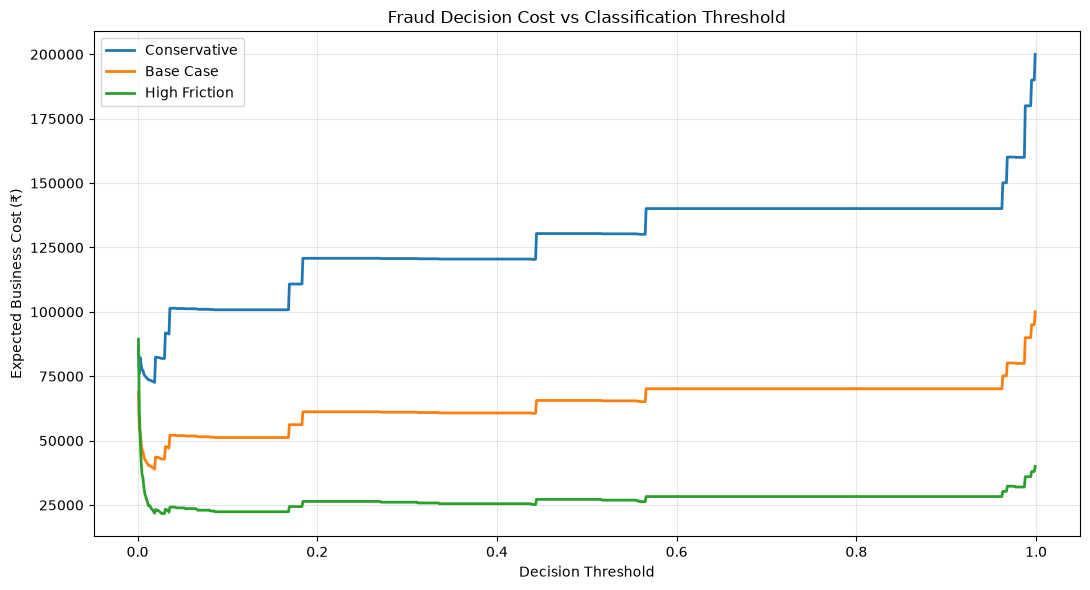

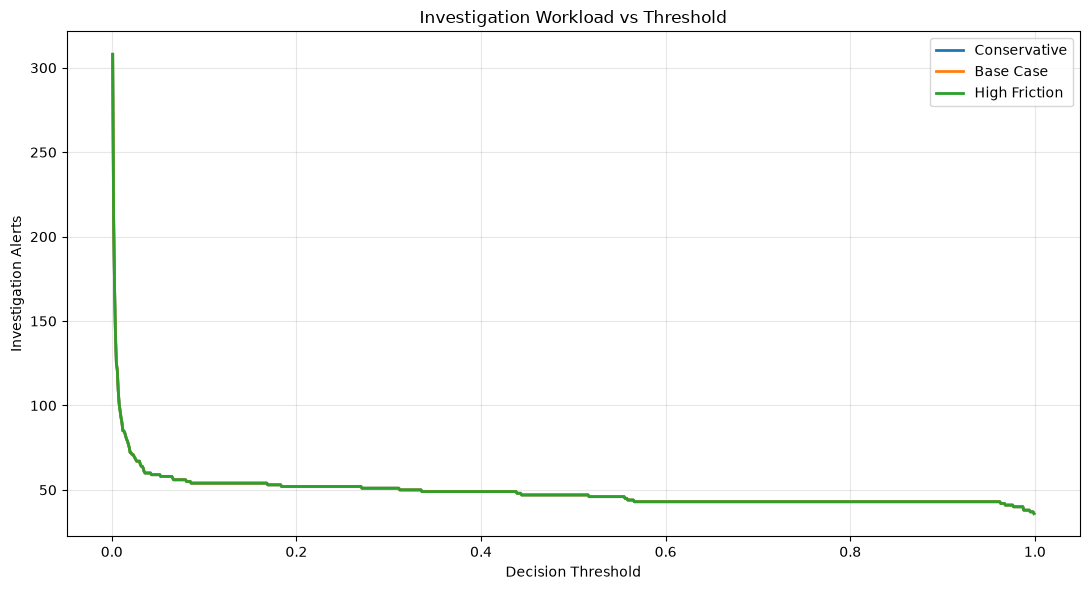


CAPACITY-CONSTRAINED OPTIMIZATION


,Scenario,Capacity,Threshold,Total Cost,Alerts,Fraud Captured,Missed Fraud,False Alarms,Precision,Recall
0,Conservative,50,0.439,120400,48,44,12,4,0.916667,0.785714
1,Conservative,100,0.019,72600,75,49,7,26,0.653333,0.875000
2,Conservative,250,0.019,72600,75,49,7,26,0.653333,0.875000
3,Conservative,500,0.019,72600,75,49,7,26,0.653333,0.875000
4,Base Case,50,0.439,60600,48,44,12,4,0.916667,0.785714
5,Base Case,100,0.019,38900,75,49,7,26,0.653333,0.875000
6,Base Case,250,0.019,38900,75,49,7,26,0.653333,0.875000
7,Base Case,500,0.019,38900,75,49,7,26,0.653333,0.875000
8,High Friction,50,0.439,25200,48,44,12,4,0.916667,0.785714
9,High Friction,100,0.027,21700,67,48,8,19,0.716418,0.857143



✓ Cost analysis saved.
✓ Optimal thresholds saved.
✓ Capacity analysis saved.

PHASE 6 COMPLETE


In [1]:
# ============================================================
# CREDIT CARD FRAUD DETECTION
# PHASE 6 — COST-BASED DECISION ENGINE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from xgboost import XGBClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)


# ============================================================
# 1. LOAD DATA
# ============================================================

DATA_PATH = Path("../data/creditcard.csv")

df = pd.read_csv(DATA_PATH)

df = df.sort_values("Time").reset_index(drop=True)


# ============================================================
# 2. TEMPORAL SPLIT
# ============================================================

n = len(df)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train = df.iloc[:train_end].copy()

validation = df.iloc[
    train_end:validation_end
].copy()

test = df.iloc[
    validation_end:
].copy()


# ============================================================
# 3. FEATURES
# ============================================================

TARGET = "Class"

FEATURES = [
    c for c in df.columns
    if c != TARGET
]

X_train = train[FEATURES]
y_train = train[TARGET]

X_validation = validation[FEATURES]
y_validation = validation[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]


# ============================================================
# 4. CLASS WEIGHT
# ============================================================

negative = (y_train == 0).sum()

positive = (y_train == 1).sum()

scale_pos_weight = negative / positive


# ============================================================
# 5. TRAIN XGBOOST
# ============================================================

model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_validation, y_validation)],
    verbose=False
)

print("✓ XGBoost trained")


# ============================================================
# 6. PREDICT VALIDATION PROBABILITIES
# ============================================================

validation_prob = model.predict_proba(
    X_validation
)[:, 1]


# ============================================================
# 7. COST SCENARIOS
# ============================================================

cost_scenarios = {

    "Conservative": {
        "fraud_cost": 10000,
        "review_cost": 100
    },

    "Base Case": {
        "fraud_cost": 5000,
        "review_cost": 150
    },

    "High Friction": {
        "fraud_cost": 2000,
        "review_cost": 300
    }
}


# ============================================================
# 8. COST-OPTIMAL THRESHOLD
# ============================================================

thresholds = np.arange(
    0.001,
    1.000,
    0.001
)

all_results = []


for scenario, costs in cost_scenarios.items():

    fraud_cost = costs["fraud_cost"]

    review_cost = costs["review_cost"]

    for threshold in thresholds:

        predicted_fraud = (
            validation_prob >= threshold
        )

        actual_fraud = (
            y_validation.values == 1
        )

        actual_legitimate = (
            y_validation.values == 0
        )

        # Fraud approved = missed fraud
        false_negatives = np.sum(
            actual_fraud &
            (~predicted_fraud)
        )

        # Legitimate transactions investigated
        false_positives = np.sum(
            actual_legitimate &
            predicted_fraud
        )

        # Economic cost
        total_cost = (
            false_negatives * fraud_cost
            +
            false_positives * review_cost
        )

        alerts = predicted_fraud.sum()

        fraud_captured = np.sum(
            actual_fraud &
            predicted_fraud
        )

        total_fraud = actual_fraud.sum()

        recall = (
            fraud_captured / total_fraud
            if total_fraud > 0
            else 0
        )

        precision = (
            fraud_captured / alerts
            if alerts > 0
            else 0
        )

        all_results.append({

            "Scenario": scenario,

            "Fraud Cost": fraud_cost,

            "Review Cost": review_cost,

            "Threshold": threshold,

            "Total Cost": total_cost,

            "Alerts": alerts,

            "Fraud Captured": fraud_captured,

            "Missed Fraud": false_negatives,

            "False Alarms": false_positives,

            "Precision": precision,

            "Recall": recall
        })


cost_results = pd.DataFrame(
    all_results
)


# ============================================================
# 9. FIND COST-OPTIMAL THRESHOLDS
# ============================================================

optimal_rows = []

for scenario in cost_scenarios:

    scenario_data = cost_results[
        cost_results["Scenario"] == scenario
    ]

    best = scenario_data.loc[
        scenario_data["Total Cost"].idxmin()
    ]

    optimal_rows.append(best)


optimal_results = pd.DataFrame(
    optimal_rows
).reset_index(drop=True)


# ============================================================
# 10. DISPLAY OPTIMAL RESULTS
# ============================================================

print("\n" + "=" * 80)
print("COST-OPTIMAL DECISIONS")
print("=" * 80)

display(
    optimal_results[
        [
            "Scenario",
            "Fraud Cost",
            "Review Cost",
            "Threshold",
            "Total Cost",
            "Alerts",
            "Fraud Captured",
            "Missed Fraud",
            "False Alarms",
            "Precision",
            "Recall"
        ]
    ]
)


# ============================================================
# 11. THEORETICAL BREAK-EVEN THRESHOLD
# ============================================================

print("\n" + "=" * 80)
print("THEORETICAL COST THRESHOLDS")
print("=" * 80)

theoretical_thresholds = []

for scenario, costs in cost_scenarios.items():

    fraud_cost = costs["fraud_cost"]

    review_cost = costs["review_cost"]

    threshold = (
        review_cost /
        (fraud_cost + review_cost)
    )

    theoretical_thresholds.append({

        "Scenario": scenario,

        "Fraud Cost": fraud_cost,

        "Review Cost": review_cost,

        "Theoretical Threshold": threshold
    })


theoretical_thresholds = pd.DataFrame(
    theoretical_thresholds
)

display(theoretical_thresholds)


# ============================================================
# 12. COST CURVES
# ============================================================

plt.figure(figsize=(11, 6))

for scenario in cost_scenarios:

    scenario_data = cost_results[
        cost_results["Scenario"] == scenario
    ]

    plt.plot(
        scenario_data["Threshold"],
        scenario_data["Total Cost"],
        label=scenario,
        linewidth=2
    )


plt.xlabel("Decision Threshold")

plt.ylabel("Expected Business Cost (₹)")

plt.title(
    "Fraud Decision Cost vs Classification Threshold"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 13. ALERT VOLUME VS THRESHOLD
# ============================================================

plt.figure(figsize=(11, 6))

for scenario in cost_scenarios:

    scenario_data = cost_results[
        cost_results["Scenario"] == scenario
    ]

    plt.plot(
        scenario_data["Threshold"],
        scenario_data["Alerts"],
        label=scenario,
        linewidth=2
    )


plt.xlabel("Decision Threshold")

plt.ylabel("Investigation Alerts")

plt.title(
    "Investigation Workload vs Threshold"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 14. CAPACITY CONSTRAINT
# ============================================================

capacity_levels = [
    10,
    25,
    50,
    100,
    250,
    500
]


capacity_results = []


for scenario in cost_scenarios:

    scenario_data = cost_results[
        cost_results["Scenario"] == scenario
    ].copy()

    for capacity in capacity_levels:

        feasible = scenario_data[
            scenario_data["Alerts"] <= capacity
        ]

        if len(feasible) == 0:

            continue

        best = feasible.loc[
            feasible["Total Cost"].idxmin()
        ]

        capacity_results.append({

            "Scenario": scenario,

            "Capacity": capacity,

            "Threshold": best["Threshold"],

            "Total Cost": best["Total Cost"],

            "Alerts": best["Alerts"],

            "Fraud Captured": best["Fraud Captured"],

            "Missed Fraud": best["Missed Fraud"],

            "False Alarms": best["False Alarms"],

            "Precision": best["Precision"],

            "Recall": best["Recall"]
        })


capacity_results = pd.DataFrame(
    capacity_results
)


# ============================================================
# 15. DISPLAY CAPACITY RESULTS
# ============================================================

print("\n" + "=" * 80)
print("CAPACITY-CONSTRAINED OPTIMIZATION")
print("=" * 80)

display(
    capacity_results
)


# ============================================================
# 16. SAVE RESULTS
# ============================================================

cost_results.to_csv(
    "../reports/cost_threshold_analysis.csv",
    index=False
)

optimal_results.to_csv(
    "../reports/cost_optimal_thresholds.csv",
    index=False
)

capacity_results.to_csv(
    "../reports/capacity_constrained_decisions.csv",
    index=False
)

print("\n✓ Cost analysis saved.")
print("✓ Optimal thresholds saved.")
print("✓ Capacity analysis saved.")


# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 80)
print("PHASE 6 COMPLETE")
print("=" * 80)